"""
Goal:

Transform observational churn data into a synthetic
uplift-learning dataset.

We need:

1. Treatment assignment
2. Treatment effect simulation
3. Outcome generation
"""

Load Feature Engineered Data

In [155]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")

In [156]:
df = pd.read_csv("/content/enhanced_telco.csv")


df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureBucket,FamilyIndicator,SupportBundle,StreamingBundle
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,0,2,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,0,2,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,0,3,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,0,0


Dataset shape

In [157]:
df.shape

(7043, 25)

Columns

In [158]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureBucket',
 'FamilyIndicator',
 'SupportBundle',
 'StreamingBundle']

Target distribution

In [159]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [160]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


Check Important Features

In [161]:
important_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

df[important_cols].describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928,0.162147
std,24.559481,30.090047,2265.270398,0.368612
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,402.225000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3786.600000,0.000000
max,72.000000,118.750000,8684.800000,1.000000


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Understand Churn Drivers

Senior Citizen vs Churn

In [163]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
)

Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


Contract vs Churn

In [164]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Tenure vs Churn

In [165]:
df.groupby(
    pd.cut(df["tenure"], bins=5)
)["Churn"].mean()

/tmp/ipykernel_657/2475605028.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,Churn
tenure,
"(-0.072, 14.4]",0.463518
"(14.4, 28.8]",0.261989
"(28.8, 43.2]",0.217391
"(43.2, 57.6]",0.149947
"(57.6, 72.0]",0.073292


In [166]:
df["Treatment_Prob"] = (
    0.3
    + 0.2 * (df["MonthlyCharges"] > 80)
    + 0.2 * (df["SeniorCitizen"] == 1)
    + 0.2 * (df["tenure"] < 12)
)

df["Treatment_Prob"] = np.clip(df["Treatment_Prob"], 0, 1)

df["Treatment"] = np.random.binomial(1, df["Treatment_Prob"])

In [167]:
df["Treatment"].value_counts()

,count
Treatment,
0,3766
1,3277


In [168]:
df["Treatment"].value_counts(normalize=True)

,proportion
Treatment,
0,0.534715
1,0.465285


In [169]:
pd.crosstab(
    df["Treatment"],
    df["Churn"],
    normalize="index"
)

Churn,0,1
Treatment,,
0,0.771375,0.228625
1,0.692402,0.307598


Senior Citizens by Contract

In [170]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Contract"],
    normalize="index"
)

Contract,Month-to-month,One year,Two year
SeniorCitizen,,,
0,0.519912,0.217421,0.262667
1,0.706655,0.166375,0.126970


Monthly Charges by Contract

In [171]:
df.groupby(
    "Contract"
)["MonthlyCharges"].mean()

,MonthlyCharges
Contract,
Month-to-month,66.398490
One year,65.048608
Two year,60.770413


Monthly Charges by Churn

In [172]:
df.groupby(
    "Churn"
)["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.265124
1,74.441332


Tenure by Churn

In [173]:
df.groupby(
    "Churn"
)["tenure"].mean()

,tenure
Churn,
0,37.569965
1,17.979133


Senior Citizen by Churn

In [174]:
df.groupby(
    "Churn"
)["SeniorCitizen"].mean()

,SeniorCitizen
Churn,
0,0.128721
1,0.254682


In [175]:
df["TreatmentEffect"] = (
    0.08
    + 0.12 * (df["SeniorCitizen"] == 1)
    + 0.10 * (df["MonthlyCharges"] > 80)
    + 0.08 * (df["tenure"] < 24)
)

In [176]:
df["TreatmentEffect"].describe()

,TreatmentEffect
count,7043.000000
mean,0.172705
std,0.075326
min,0.080000
25%,0.080000
50%,0.160000
75%,0.180000
max,0.380000


In [177]:
df.groupby(
    "SeniorCitizen"
)["TreatmentEffect"].mean()

,TreatmentEffect
SeniorCitizen,
0,0.149890
1,0.290595


In [178]:
df.groupby(
    df["MonthlyCharges"] > 80
)["TreatmentEffect"].mean()

,TreatmentEffect
MonthlyCharges,
False,0.135846
True,0.233218


In [179]:
df.groupby(
    df["tenure"] < 24
)["TreatmentEffect"].mean()

,TreatmentEffect
tenure,
False,0.148296
True,0.203466


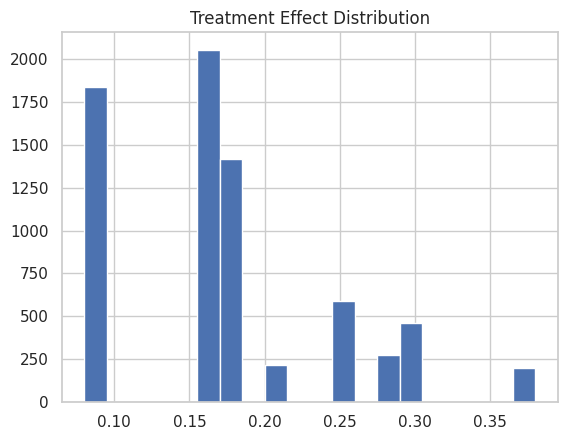

In [180]:


plt.hist(
    df["TreatmentEffect"],
    bins=20
)

plt.title("Treatment Effect Distribution")
plt.show()

In [181]:
df["BaseProb"] = (
    0.15
    + 0.15 * (df["MonthlyCharges"] > 80)
    + 0.10 * (df["SeniorCitizen"] == 1)
    + 0.20 * (df["Contract"] == "Month-to-month")
    - 0.10 * (df["tenure"] > 36)
)

In [182]:

df["BaseProb"] = np.clip(
    df["BaseProb"],
    0.01,
    0.95
)

In [183]:
df["BaseProb"].describe()

,BaseProb
count,7043.000000
mean,0.290423
std,0.158040
min,0.050000
25%,0.150000
50%,0.350000
75%,0.400000
max,0.600000


In [184]:
df.groupby("Churn")["BaseProb"].mean()

,BaseProb
Churn,
0,0.248628
1,0.406126


In [185]:
df["TreatedProb"] = df["BaseProb"] - df["TreatmentEffect"]
df["TreatedProb"] = np.clip(df["TreatedProb"], 0.01, 0.95)

In [186]:
df[["BaseProb","TreatedProb"]].describe()

,BaseProb,TreatedProb
count,7043.000000,7043.000000
mean,0.290423,0.126629
std,0.158040,0.100629
min,0.050000,0.010000
25%,0.150000,0.010000
50%,0.350000,0.170000
75%,0.400000,0.190000
max,0.600000,0.320000


In [187]:
(df["BaseProb"]- df["TreatedProb"]).describe()

,0
count,7043.000000
mean,0.163794
std,0.083991
min,0.040000
25%,0.080000
50%,0.160000
75%,0.180000
max,0.380000


In [188]:
df["Y0"] = np.random.binomial(1, 1 - df["BaseProb"])
df["Y1"] = np.random.binomial(1, 1 - df["TreatedProb"])

In [189]:
print("Retention without treatment:", df["Y0"].mean())
print("Retention with treatment:", df["Y1"].mean())

Retention without treatment: 0.7116285673718585
Retention with treatment: 0.8747692744569076


In [190]:
df["Outcome"] = np.where(
    df["Treatment"] == 1,
    df["Y1"],
    df["Y0"]
)

In [191]:
df.groupby("Treatment")["Outcome"].mean()

,Outcome
Treatment,
0,0.737122
1,0.863595


In [192]:
pd.crosstab(
    df["Treatment"],
    df["Outcome"],
    normalize="index"
)

Outcome,0,1
Treatment,,
0,0.262878,0.737122
1,0.136405,0.863595


In [193]:
df[["Treatment", "Outcome", "Y0", "Y1"]].head()

,Treatment,Outcome,Y0,Y1
0,1,1,0,1
1,0,1,1,1
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1


In [194]:
df.to_csv("simulated_uplift_data.csv", index=False)